# Comparación: Regresión Logística vs SVM (Lineal y RBF)
Dataset: `diabetes_prediction_dataset.csv`  
Objetivo: comparar modelos de **clasificación** para predecir `diabetes` (0/1) siguiendo los siguientes bloques:
1) Preparación
2) Regresión logística
3) SVM lineal
4) SVM con kernel RBF



> Nota: los cálculos pueden ralentizarse, el Dataset está en el límite de empezar a ser difícil de manejar

## 0. Importaciones

## 1) Bloque 1 — Preparación: carga y exploración
Objetivo del bloque: dejar el dataset listo para entrenar modelos.

- Detectamos columnas numéricas y categóricas.
- Hacemos `train_test_split` con `stratify=y`.
- **Escalamos** numéricas (imprescindible para SVM).
- Codificamos categóricas con One-Hot.


In [45]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


diabetes = pd.read_csv("diabetes_prediction_dataset.csv")

diabetes.head()


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [46]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [47]:
diabetes.shape

(100000, 9)

In [48]:
columnas_numericas = diabetes.select_dtypes(include=['number'])

print(columnas_numericas.columns.to_list())

['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


In [49]:
columnas_categoricas = diabetes.select_dtypes(include=['object'])

print(columnas_categoricas.columns.to_list())

['gender', 'smoking_history']


In [50]:
diabetes["gender"].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [51]:
diabetes["smoking_history"].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [52]:
diabetes = pd.get_dummies(diabetes)

diabetes.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,True,False,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,True,False,False,True,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,False,True,False,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,True,False,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,False,True,False,False,True,False,False,False,False


In [53]:
X = diabetes.drop(['diabetes'],axis=1).values #.values para que sean arrays y se puedan pintar posteriormente.
y = diabetes['diabetes'].values

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((75000, 15), (25000, 15))

In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.fit_transform(X)

### Funciones auxiliares de evaluación
Calculamos métricas estándar y pintamos:
- No olvidar Matriz de confusión

## 2) Bloque 2 — Regresión Logística
Entrenamos una regresión logística y evaluamos.



In [56]:
# Entreno el modelo con Regresión Logistica
from sklearn import linear_model

logistica = linear_model.LogisticRegression()
logistica.fit(X_train_scaled, y_train)

LogisticRegression()

In [57]:
pred_logistica = logistica.predict(X_test_scaled)


In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

Matriz de confusión:
[[22659   216]
 [  768  1357]]


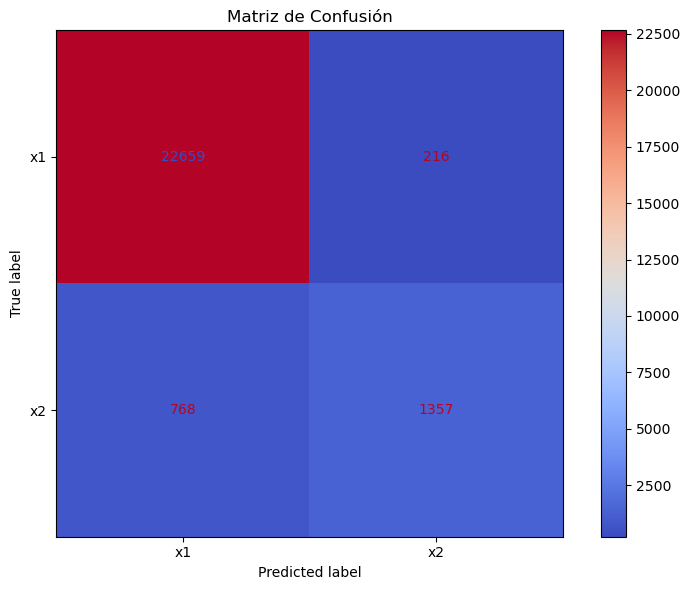

In [85]:
# Matriz de confusión - SVM Logistica

# Recalcular la matriz de confusión
cm = confusion_matrix(y_test, pred_logistica)
print("Matriz de confusión:")
print(cm)

# Crear el gráfico
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['x1', 'x2'])
disp.plot(cmap='coolwarm', ax=ax)
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

In [ ]:
print("=== SVM LOGISTICA ===")
print("Accuracy:", accuracy_score(y_test, pred_logistica)) #exactitud
print(classification_report(y_test, pred_logistica))

=== SVM LINEAL ===
Accuracy: 0.96064
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     22875
           1       0.86      0.64      0.73      2125

    accuracy                           0.96     25000
   macro avg       0.91      0.81      0.86     25000
weighted avg       0.96      0.96      0.96     25000



## 3) Bloque 3 — SVM lineal
Entrenamos una SVM con kernel lineal.



In [73]:
svm_lineal = SVC(kernel="linear", C=1.0, random_state=42, probability=True)
svm_lineal.fit(X_train_scaled, y_train)

SVC(kernel='linear', probability=True, random_state=42)

In [74]:
pred_lineal = svm_lineal.predict(X_test_scaled)

Matriz de confusión:
[[22755   120]
 [  847  1278]]


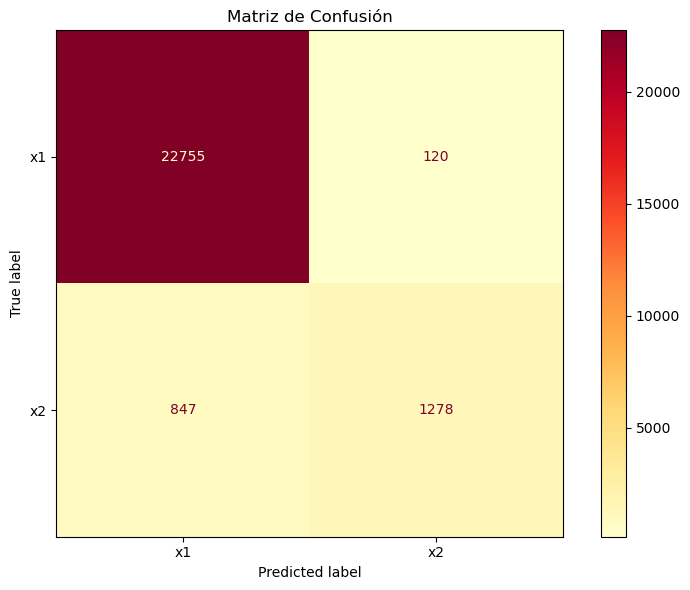

In [75]:
# Matriz de confusión - SVM Lineal

# Recalcular la matriz de confusión
cm = confusion_matrix(y_test, pred_lineal)
print("Matriz de confusión:")
print(cm)

# Crear el gráfico
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['x1', 'x2'])
disp.plot(cmap='YlOrRd', ax=ax)
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

In [76]:
print("=== SVM LINEAL ===")
print("Accuracy:", accuracy_score(y_test, pred_lineal)) #exactitud
print(classification_report(y_test, pred_lineal))

=== SVM LINEAL ===
Accuracy: 0.96132
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     22875
           1       0.91      0.60      0.73      2125

    accuracy                           0.96     25000
   macro avg       0.94      0.80      0.85     25000
weighted avg       0.96      0.96      0.96     25000



## 4) Bloque 4 — SVM con kernel RBF
Entrenamos una SVM con kernel gaussiano (RBF).



In [81]:
svm_rbf = SVC(kernel="rbf", C=1.0, gamma=0.1, random_state=42, probability=True)
svm_rbf.fit(X_train_scaled, y_train)

SVC(gamma=0.1, probability=True, random_state=42)

In [65]:
pred_rbf = svm_rbf.predict(X_test_scaled)

Matriz de confusión:
[[22525   350]
 [  980  1145]]


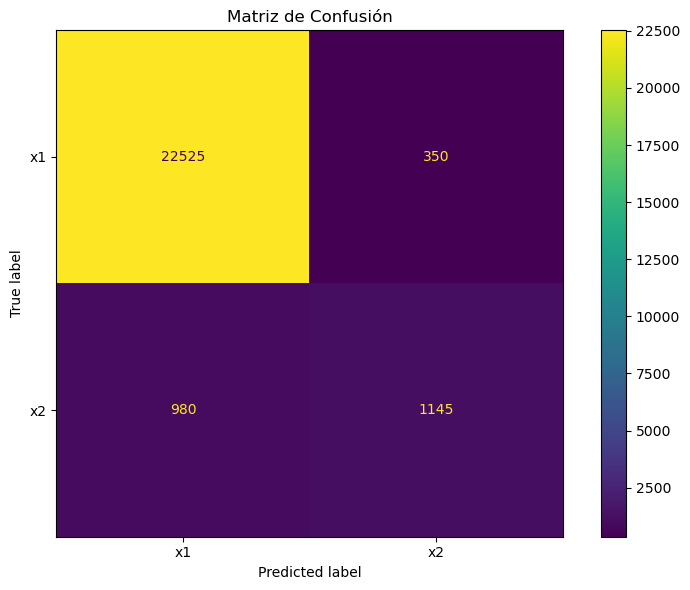

In [72]:
# Matriz de confusión - SVM RBF

# Recalcular la matriz de confusión
cm = confusion_matrix(y_test, pred_rbf)
print("Matriz de confusión:")
print(cm)

# Crear el gráfico
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['x1', 'x2'])
disp.plot(cmap='viridis', ax=ax)
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

In [ ]:
print("=== SVM RBF ===")
print("Accuracy:", accuracy_score(y_test, pred_rbf)) #exactitud
print(classification_report(y_test, pred_rbf))

## 5) Resumen
Comparamos resultados en una tabla.

### Preguntas
1. ¿Qué modelo tiene mejor **recall** para la clase positiva (`diabetes=1`)?
2. En un contexto médico, ¿qué error es más grave: **FP** o **FN**? Explica.
3. ¿Qué modelo escogerías si tu prioridad es **interpretabilidad**? ¿y si tu prioridad es **rendimiento**?
4. ¿Por qué el escalado afecta más a SVM que a la logística?
5. Si el dataset está desbalanceado, ¿qué métrica sería más fiable que accuracy?

AUC del modelo: 0.9614


/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


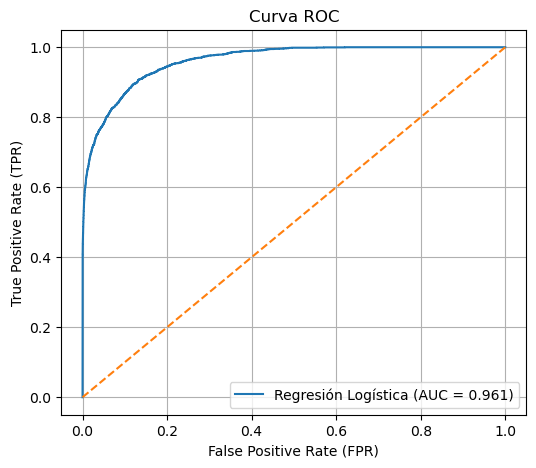

In [ ]:
# ============================================================
# Cálculo y visualización de la curva ROC y del AUC
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
# Para variar la curva ROC en regresión logística debes modificar:

# C (regularización)

# penalty (consultar documentación oficial)

# Datos de entrenamiento
# ============================================================

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# 1️. Entrenamos modelo (si no lo estuviera ya)
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# 2️. Obtenemos probabilidades de la clase positiva
y_prob = modelo.predict_proba(X_test)[:, 1]

# 3️. Calculamos puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# 4️. Calculamos AUC
auc = roc_auc_score(y_test, y_prob)

print(f"AUC del modelo: {auc:.4f}")

# 5️. Representación gráfica
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Regresión Logística (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")  # Línea diagonal (modelo aleatorio)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Curva ROC")
plt.legend()
plt.grid()
plt.show()


AUC del modelo: 0.9599


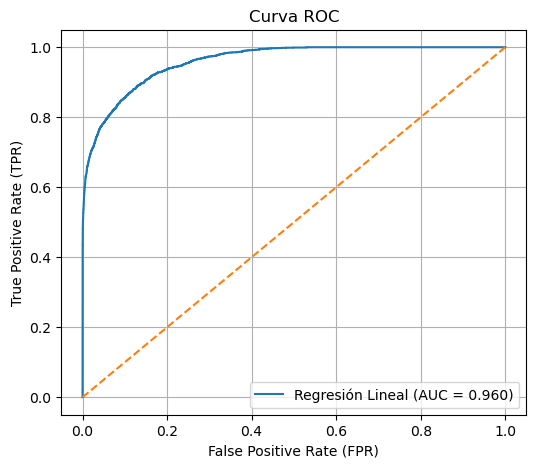

In [83]:
# 2️. Obtenemos probabilidades de la clase positiva
y_prob = svm_lineal.predict_proba(X_test_scaled)[:, 1]

# 3️. Calculamos puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# 4️. Calculamos AUC
auc = roc_auc_score(y_test, y_prob)

print(f"AUC del modelo: {auc:.4f}")

# 5️. Representación gráfica
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Regresión Lineal (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")  # Línea diagonal (modelo aleatorio)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Curva ROC")
plt.legend()
plt.grid()
plt.show()

AUC del modelo: 0.9083


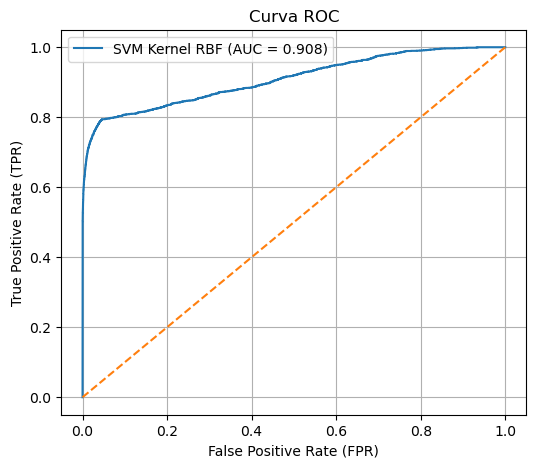

In [84]:
# 2️. Obtenemos probabilidades de la clase positiva
y_prob = svm_rbf.predict_proba(X_test_scaled)[:, 1]

# 3️. Calculamos puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# 4️. Calculamos AUC
auc = roc_auc_score(y_test, y_prob)

print(f"AUC del modelo: {auc:.4f}")

# 5️. Representación gráfica
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"SVM Kernel RBF (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")  # Línea diagonal (modelo aleatorio)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Curva ROC")
plt.legend()
plt.grid()
plt.show()